In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("final_model_data.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Date range:", df["DATE"].min(), "to", df["DATE"].max())
print("Number of observations:", len(df))

Date range: 2010-10-05 00:00:00 to 2025-09-09 00:00:00
Number of observations: 3894


In [4]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-05,0,Pre-2022
1,2010-10-06,0,Pre-2022
2,2010-10-07,0,Pre-2022
3,2010-10-08,0,Pre-2022
4,2010-10-11,0,Pre-2022


In [5]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-05,0,Pre-2022
1,2010-10-06,0,Pre-2022
2,2010-10-07,0,Pre-2022
3,2010-10-08,0,Pre-2022
4,2010-10-11,0,Pre-2022


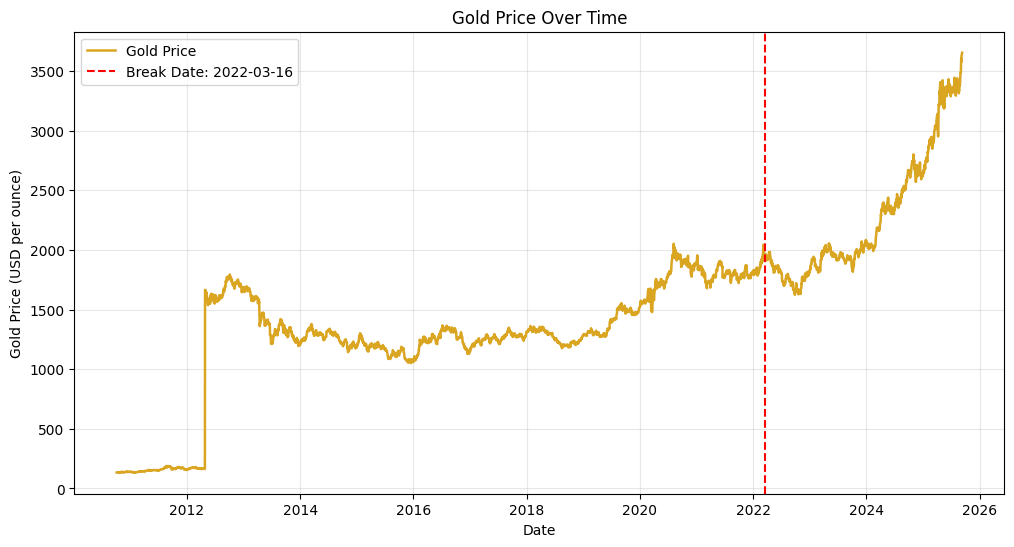

In [6]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_MGC_F"], color="goldenrod", linewidth=1.8, label="Gold Price")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Figure 1: Gold Prices Over Time 

This figure provides a first descriptive view of gold prices over the full sample period, with March 16, 2022 marked as the structural break date used throughout this project. Looking at the series over time is an important starting point because the main goal of the project is to evaluate the **Broken Haven hypothesis**: whether gold's traditional safe-haven behavior appears weaker or less stable in the post-2022 environment.

From the time-series pattern alone, gold prices clearly do not move in a perfectly stable way across the sample. Instead, the series passes through different market conditions before and after the chosen break date. This does not, by itself, prove that gold's role changed. A univariate time-series plot cannot tell us whether gold became a weaker hedge, whether its response to stress shifted, or whether any change is statistically meaningful. However, it does establish that the post-break period is not just an arbitrary extension of the earlier sample. Visually, the market environment surrounding gold appears to have evolved, which gives a reason to investigate whether the underlying pricing relationship also changed.

This plot therefore plays a framing role in the project. It shows why it is reasonable to split the sample into pre-break and post-break regimes and why later sections focus on out-of-sample performance and structural change. In particular, if the relationship governing gold prices remained stable over time, then models trained on earlier data should continue to perform reasonably well after the break. If they do not, that would be more consistent with the Broken Haven idea that the newer regime behaves differently from the earlier one.

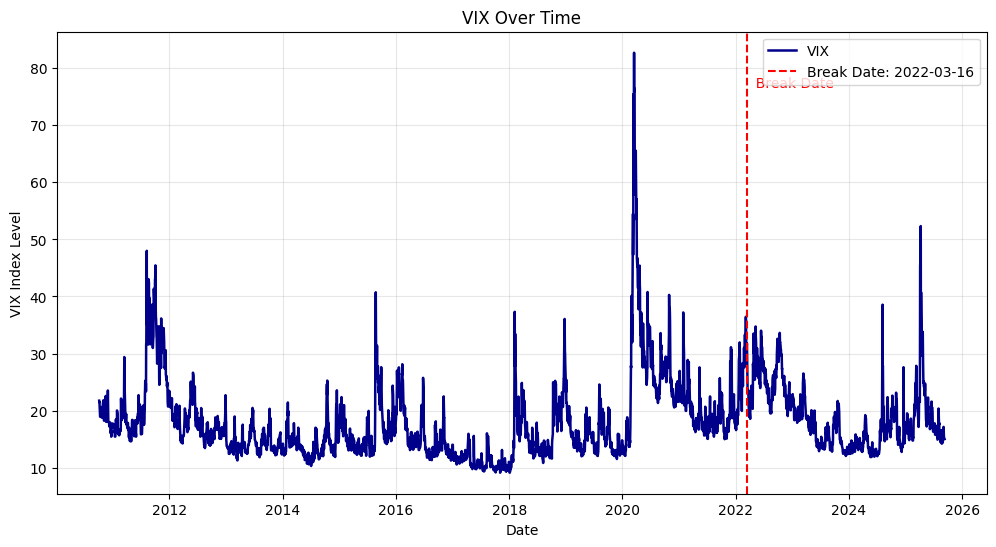

In [7]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_VIX"], color="darkblue", linewidth=1.8, label="VIX")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("VIX Over Time")
plt.xlabel("Date")
plt.ylabel("VIX Index Level")
plt.legend()
plt.grid(alpha=0.3)

y_max = df["Close_VIX"].max()
plt.text(split_date, y_max * 0.95, "  Break Date", color="red", va="top")

plt.show()

### Figure 2: VIX Over Time 

The VIX is used in this project as a proxy for market stress and uncertainty, making it one of the central variables for evaluating whether gold still behaves like a safe haven. Since the Broken Haven hypothesis is about a possible change in gold's response to stress, it is not enough to look at gold prices alone. We also need to understand whether the broader stress environment itself looks different before and after the break date.

This figure shows that market stress is not constant across time. The VIX moves through periods of relatively lower and higher uncertainty, and the post-break period appears to reflect a volatility environment that is not identical to the earlier sample. This matters because the interpretation of gold depends on the conditions under which it is being observed. If stress conditions changed, then a stable safe-haven asset might still be expected to react systematically to that stress. But if gold's pricing relationship became less reliable or less responsive in the newer regime, then the connection between gold and stress could weaken even when stress remains economically important.

For that reason, this figure provides essential context for the later modeling sections. The regression analysis will test whether the relationship between gold and explanatory variables remains stable, while the machine-learning section will ask whether patterns learned from the pre-break period still generalize to the post-break period. In that sense, the VIX plot motivates why the project focuses not just on price levels, but on whether gold continues to co-move with market stress in a predictable way.